# Notebook 04 – Supervised Regression: Kundenumsatz vorhersagen

Dieses Notebook schließt die ML-Analyse ab und ergänzt die bisherigen Schritte
um einen Regressions-Ansatz.

Während Notebook 03 Kunden in Klassen einteilt (*High-Value* vs. *Normal*),
wird hier der **genaue Kundenumsatz** als kontinuierliche Zielgröße vorhergesagt.

**Projektablauf (Übersicht):**
1. Notebook 01: Datenbereinigung und Exploration
2. Notebook 02: Unsupervised Learning – Kundensegmentierung
3. Notebook 03: Supervised Classification – High-Value-Customer
4. **Notebook 04: Supervised Regression – Kundenumsatz vorhersagen** ← hier

**Ablauf dieses Notebooks:**
1. Bereinigten Datensatz laden
2. Kundendaten aggregieren
3. Zielvariable und Features definieren
4. Verteilung explorieren und Log-Transformation anwenden
5. Train-Test-Split
6. Drei Regressionsmodelle trainieren
7. Modelle vergleichen und auswerten

## 1. Bibliotheken importieren

In [59]:
# Datenverarbeitung
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt

# Machine Learning: Modelle, Pipeline und Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Bereinigten Datensatz laden

Wir verwenden den in Notebook 01 erstellten bereinigten Datensatz.

In [60]:
df = pd.read_csv(
    "../data/online_retail_data_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

/tmp/ipykernel_20076/311456575.py:1: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,False
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False


## 3. Kundendaten aggregieren

Wie in Notebook 03 wird der Transaktionsdatensatz auf Kundenebene aggregiert.
Zusätzlich wird hier die **Kundendauer** (`customer_lifetime_days`) berechnet:
die Anzahl der Tage zwischen erster und letzter Bestellung.

In [61]:
customer_data = df.groupby("CustomerID").agg(
    total_revenue=("TotalPrice", "sum"),
    number_of_orders=("InvoiceNo", "nunique"),
    total_quantity=("Quantity", "sum"),
    unique_products=("StockCode", "nunique"),
    avg_unit_price=("UnitPrice", "mean"),
    first_order=("InvoiceDate", "min"),
    last_order=("InvoiceDate", "max")
).reset_index()

# Zeitraum zwischen erster und letzter Bestellung in Tagen
customer_data["customer_lifetime_days"] = (
    customer_data["last_order"] - customer_data["first_order"]
).dt.days

# Datumsspalten werden nicht als Features verwendet
customer_data = customer_data.drop(columns=["first_order", "last_order"])

customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,unique_products,avg_unit_price,customer_lifetime_days
0,12346.0,77183.60,1,74215.0,1,1.040000,0
1,12347.0,4310.00,7,2458.0,103,2.644011,365
2,12348.0,1797.24,4,2341.0,22,5.764839,282
3,12349.0,1757.55,1,631.0,73,8.289041,0
4,12350.0,334.40,1,197.0,17,3.841176,0


## 4. Zielvariable und Features definieren

**Zielvariable:** `total_revenue` – der Gesamtumsatz pro Kunde

**Features:** verhaltensbasierte Kundenmerkmale, die *nicht* direkt den Umsatz enthalten
(Data Leakage vermeiden):
- `number_of_orders`: Anzahl der Bestellungen
- `total_quantity`: Gesamtmenge der gekauften Artikel
- `unique_products`: Anzahl unterschiedlicher Produkte
- `avg_unit_price`: Durchschnittlicher Stückpreis
- `customer_lifetime_days`: Zeitraum der Kundenaktivität

In [62]:
features = [
    "number_of_orders",
    "total_quantity",
    "unique_products",
    "avg_unit_price",
    "customer_lifetime_days"
]

X = customer_data[features]
y = customer_data["total_revenue"]

print(f"Feature-Matrix: {X.shape}")
print(f"Zielvariable:   {y.shape}")

Feature-Matrix: (4338, 5)
Zielvariable:   (4338,)


## 5. Zielvariable explorieren

Vor dem Training schauen wir uns die Verteilung des Kundenumsatzes an.
Bei Retail-Daten ist der Umsatz typischerweise stark rechtschief verteilt.

In [63]:
# Statistische Übersicht
customer_data[["total_revenue"] + features].describe()

,total_revenue,number_of_orders,total_quantity,unique_products,avg_unit_price,customer_lifetime_days
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,2054.266460,4.272476,1191.289073,61.482250,4.467773,130.448594
std,8989.230441,7.698551,5046.081546,85.333637,34.211451,132.039554
min,3.750000,1.000000,1.000000,1.000000,0.122500,0.000000
25%,307.415000,1.000000,160.000000,16.000000,2.203728,0.000000
50%,674.485000,2.000000,379.000000,35.000000,2.917611,92.500000
75%,1661.740000,5.000000,992.750000,77.000000,3.829784,251.750000
max,280206.020000,209.000000,196915.000000,1786.000000,2033.100000,373.000000


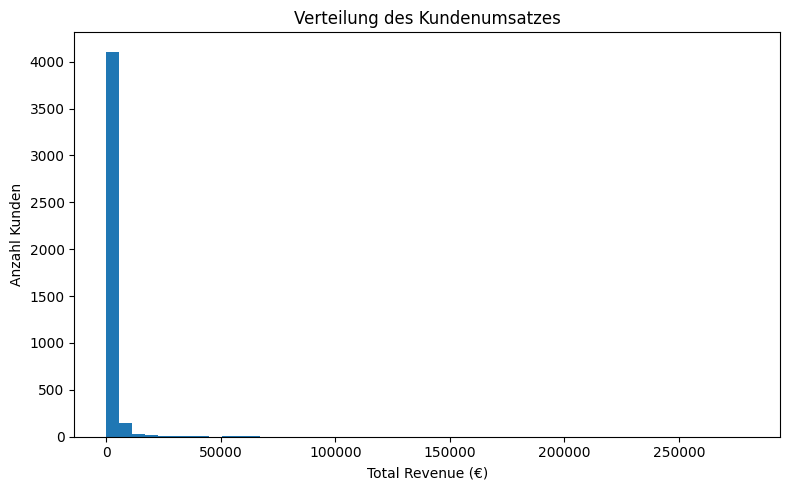

In [64]:
# Histogramm des Kundenumsatzes (Rohdaten)
plt.figure(figsize=(8, 5))
plt.hist(customer_data["total_revenue"], bins=50)
plt.title("Verteilung des Kundenumsatzes")
plt.xlabel("Total Revenue (€)")
plt.ylabel("Anzahl Kunden")
plt.tight_layout()
plt.savefig("../output/04_umsatzverteilung_roh.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Log-Transformation der Zielvariable

Da der Umsatz stark rechtschief verteilt ist, wird eine Log-Transformation
der Zielvariable angewendet. Das stabilisiert das Training und reduziert
den Einfluss extremer Ausreißer.

`np.log1p(x)` berechnet log(1 + x) und funktioniert auch für Werte nahe 0.
Die Rücktransformation für die Evaluation erfolgt mit `np.expm1()`.

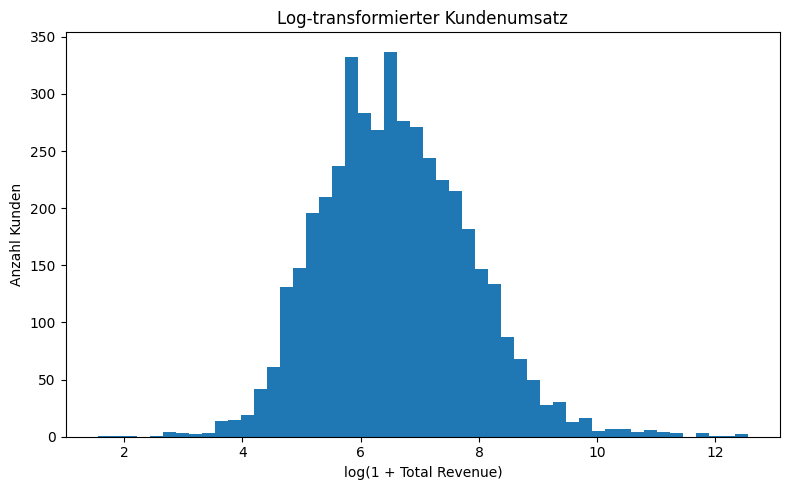

In [65]:
y_log = np.log1p(y)

# Verteilung nach Log-Transformation
plt.figure(figsize=(8, 5))
plt.hist(y_log, bins=50)
plt.title("Log-transformierter Kundenumsatz")
plt.xlabel("log(1 + Total Revenue)")
plt.ylabel("Anzahl Kunden")
plt.tight_layout()
plt.savefig("../output/04_umsatzverteilung_log.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Train-Test-Split

80 % der Daten werden für das Training verwendet, 20 % für die Evaluation.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print(f"Trainingsdaten: {X_train.shape}")
print(f"Testdaten:      {X_test.shape}")

Trainingsdaten: (3470, 5)
Testdaten:      (868, 5)


## 8. Regressionsmodelle trainieren

Drei Modelle werden verglichen:

1. **Lineare Regression**: einfaches Baseline-Modell, setzt lineare Zusammenhänge voraus
2. **Decision Tree Regression**: kann nichtlineare Zusammenhänge erfassen
3. **Polynomial Regression (Grad 2)**: erweitert die lineare Regression um quadratische Terme

Alle Modelle werden in einer Pipeline mit StandardScaler kombiniert,
damit die Skalierung korrekt nur auf den Trainingsdaten gelernt wird.

In [67]:
# Modell 1: Lineare Regression
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

In [68]:
# Modell 2: Decision Tree Regression (max_depth=5 zur Vermeidung von Overfitting)
tree_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeRegressor(max_depth=5, random_state=42))
])
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

In [69]:
# Modell 3: Polynomial Regression (Grad 2)
# Achtung: Quadratische Terme können bei Ausreißern zu starkem Overfitting führen
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])
poly_model.fit(X_train, y_train)
poly_predictions = poly_model.predict(X_test)

## 9. Modelle bewerten

Drei Metriken werden verwendet:

- **MAE** (Mean Absolute Error): durchschnittlicher absoluter Fehler in €
- **RMSE** (Root Mean Squared Error): bestraft große Abweichungen stärker
- **R²** (Bestimmtheitsmaß): Anteil der erklärten Varianz (auf log-Skala)

MAE und RMSE werden auf der **Originalskala** (nicht log) berechnet,
damit sie in Euro interpretierbar sind.

In [70]:
def evaluate_model(model_name, y_test_log, predictions_log):
    """Berechnet MAE, RMSE und R² für ein Regressionsmodell.
    MAE und RMSE werden auf der Originalskala (€) ausgegeben."""
    y_test_original = np.expm1(y_test_log)
    predictions_original = np.expm1(predictions_log)

    mae = mean_absolute_error(y_test_original, predictions_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, predictions_original))
    r2 = r2_score(y_test_log, predictions_log)

    return {
        "Modell": model_name,
        "MAE (€)": round(mae, 2),
        "RMSE (€)": round(rmse, 2),
        "R² (log)": round(r2, 4)
    }

results = [
    evaluate_model("Lineare Regression", y_test, linear_predictions),
    evaluate_model("Decision Tree Regression", y_test, tree_predictions),
    evaluate_model("Polynomial Regression", y_test, poly_predictions)
]

results_df = pd.DataFrame(results)
results_df

,Modell,MAE (€),RMSE (€),R² (log)
0,Lineare Regression,3701.48,5.406310e+04,0.6205
1,Decision Tree Regression,717.79,4.084880e+03,0.8969
2,Polynomial Regression,77505901.68,2.283357e+09,0.5994


## 10. Ergebnisse visualisieren

MAE und R² der Modelle werden als Balkendiagramme verglichen.

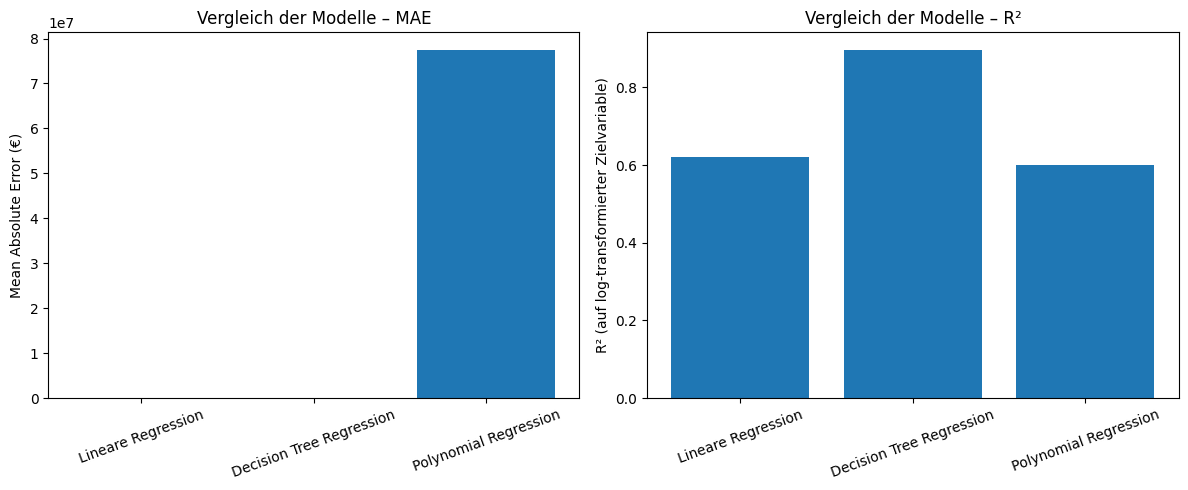

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE Vergleich
axes[0].bar(results_df["Modell"], results_df["MAE (€)"])
axes[0].set_title("Vergleich der Modelle – MAE")
axes[0].set_ylabel("Mean Absolute Error (€)")
axes[0].tick_params(axis="x", rotation=20)

# R² Vergleich
axes[1].bar(results_df["Modell"], results_df["R² (log)"])
axes[1].set_title("Vergleich der Modelle – R²")
axes[1].set_ylabel("R² (auf log-transformierter Zielvariable)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../output/04_modellvergleich_mae_r2.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Bestes Modell auswählen und visualisieren

Das Modell mit dem niedrigsten MAE wird als bestes Modell ausgewählt.
**Hinweis zur Polynomial Regression:** Durch die quadratischen Terme und
Ausreißer im Datensatz kann es zu extremem Overfitting kommen – der MAE
kann dabei in unrealistische Bereiche steigen. Das ist ein bekanntes Problem
bei Polynomregressionen auf schief verteilten Retail-Daten.

Bestes Modell nach MAE: Decision Tree Regression


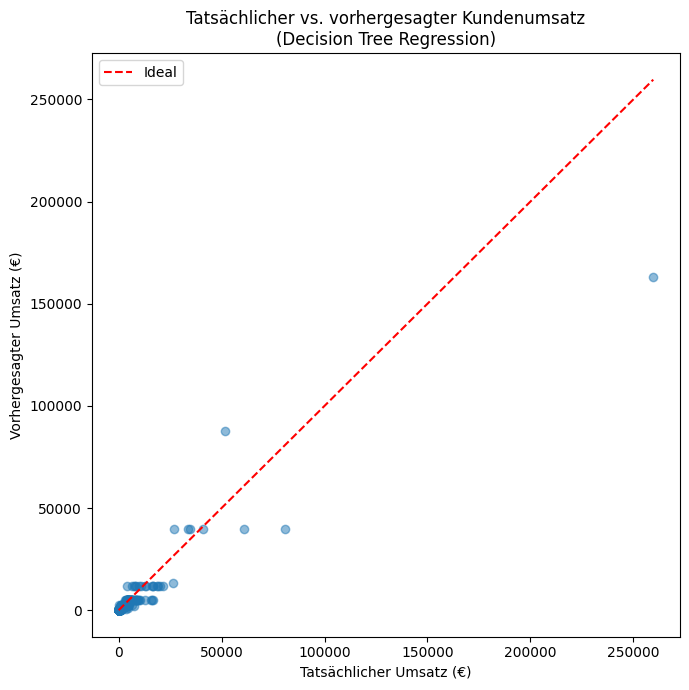

In [72]:
# Bestes Modell nach niedrigstem MAE
best_model_name = results_df.sort_values("MAE (€)").iloc[0]["Modell"]
print(f"Bestes Modell nach MAE: {best_model_name}")

# Vorhersagen des Decision Trees für die Visualisierung
y_test_original = np.expm1(y_test)
predictions_original = np.expm1(tree_predictions)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_original, predictions_original, alpha=0.5)

# Ideale Linie (y = x): hier wären Vorhersage und Realität identisch
max_val = max(y_test_original.max(), predictions_original.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Ideal")

plt.title("Tatsächlicher vs. vorhergesagter Kundenumsatz\n(Decision Tree Regression)")
plt.xlabel("Tatsächlicher Umsatz (€)")
plt.ylabel("Vorhergesagter Umsatz (€)")
plt.legend()
plt.tight_layout()
plt.savefig("../output/04_tatsaechlich_vs_vorhergesagt.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Fazit

In diesem Notebook wurde der Kundenumsatz mithilfe von Supervised Regression vorhergesagt.

**Modellergebnisse (Zusammenfassung):**
- Die **Decision Tree Regression** liefert das beste Ergebnis (niedrigster MAE, höchstes R²)
- Die **lineare Regression** ist ein solides Baseline-Modell
- Die **Polynomial Regression** zeigt in diesem Datensatz Overfitting:
  Ausreißer im Retail-Umsatz führen bei quadratischen Termen zu extremen Fehlern

**Zusammenfassung des Gesamtprojekts:**
Das Projekt hat drei komplementäre ML-Ansätze auf demselben Datensatz demonstriert:
- Unsupervised Learning zur Kundensegmentierung (Notebook 02)
- Klassifikation zur Identifikation wertvoller Kunden (Notebook 03)
- Regression zur Vorhersage des konkreten Kundenumsatzes (Notebook 04)